In [139]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [140]:
# ---------------------------
# Parameters
# ---------------------------

Delta_p = 2
Delta_s = 6
Delta_i = 6
s = 10.0


In [141]:
# def test_3mode(t, y):
#     a_p = y[0] + 1j*y[1]
#     a_s = y[2] + 1j*y[3]
#     a_i = y[4] + 1j*y[5]

#     da_p = a_p*(-1 - 1j*Delta_p) - 1j*(2*a_i*a_p*np.conj(a_i) + np.abs(a_p)**2*np.conj(a_p) + 2*a_i*a_s*np.conj(a_p) + 2*a_p*a_s*np.conj(a_s)) + s

#     da_s = a_s*(-1 - 1j*Delta_s) - 1j*(np.abs(a_p)**2*np.conj(a_i) + 2*a_i*a_s*np.conj(a_i) + 2*a_p*a_s*np.conj(a_p) + np.abs(a_s)**2*np.conj(a_s))

#     da_i = a_i*(-1 - 1j*Delta_i) - 1j*(np.abs(a_i)**2*np.conj(a_i) + 2*a_i*a_p*np.conj(a_p) + np.abs(a_p)**2*np.conj(a_s) + 2*a_i*a_s*np.conj(a_s))

#     return [
#         np.real(da_p), 
#         np.imag(da_p), 
#         np.real(da_s), 
#         np.imag(da_s), 
#         np.real(da_i), 
#         np.imag(da_i)
#         ]




def test_3mode(t, y):

    ap = y[0] + 1j*y[1]
    a_s = y[2] + 1j*y[3]
    a_i = y[4] + 1j*y[5]

    dap = -(1+1j*Delta_p)*ap \
          -1j*( np.abs(ap)**2*ap
                +2*np.abs(a_s)**2*ap
                +2*np.abs(a_i)**2*ap
                +2*a_s*a_i*np.conj(ap) ) \
          + s

    das = -(1+1j*Delta_s)*a_s \
          -1j*( 2*np.abs(ap)**2*a_s
                +np.abs(a_s)**2*a_s
                +2*np.abs(a_i)**2*a_s
                +ap**2*np.conj(a_i) )

    dai = -(1+1j*Delta_i)*a_i \
          -1j*( 2*np.abs(ap)**2*a_i
                +np.abs(a_i)**2*a_i
                +2*np.abs(a_s)**2*a_i
                +ap**2*np.conj(a_s) )

    return [
        np.real(dap), np.imag(dap),
        np.real(das), np.imag(das),
        np.real(dai), np.imag(dai)
    ]

In [142]:

# ---------------------------
# ODE system
# ---------------------------

def cmt_3mode(t, y):

      ap = y[0] + 1j*y[1]
      a_s = y[2] + 1j*y[3]
      a_i = y[4] + 1j*y[5]

      dap = -(1+1j*Delta_p)*ap \
            -1j*(abs(ap)**2 + 2*abs(a_s)**2 + 2*abs(a_i)**2)*ap \
            -1j*2*a_s*a_i*np.conj(ap) \
            + s

      das = -(1+1j*Delta_s)*a_s \
            -1j*(abs(a_s)**2 + 2*abs(ap)**2 + 2*abs(a_i)**2)*a_s \
            -1j*(ap**2)*np.conj(a_i)

      dai = -(1+1j*Delta_i)*a_i \
            -1j*(abs(a_i)**2 + 2*abs(ap)**2 + 2*abs(a_s)**2)*a_i \
            -1j*(ap**2)*np.conj(a_s)
    
      noise_strength = 1e-6

      das += noise_strength*(np.random.randn()+1j*np.random.randn())
      dai += noise_strength*(np.random.randn()+1j*np.random.randn())

      return [
            np.real(dap),
            np.imag(dap),
            np.real(das),
            np.imag(das),
            np.real(dai),
            np.imag(dai)
      ]


In [143]:
# ---------------------------
# Initial conditions
# ---------------------------

# y0 = [0,0,   # pump
#       1e-6,0, # signal (vacuum seed)
#       1e-6,0] # idler


noise = 1e-1

y0 = [
1,0,                                      # pump
noise*np.random.randn(), noise*np.random.randn(),   # signal
noise*np.random.randn(), noise*np.random.randn()    # idler
]


In [144]:
# ---------------------------
# Time span
# ---------------------------

t_span = (0, 200)
t_eval = np.linspace(0,200,4000)


In [148]:

sol = solve_ivp(test_3mode, t_span, y0, t_eval=t_eval,
        rtol=1e-8,
        atol=1e-10
)


In [149]:

# ---------------------------
# Recover amplitudes
# ---------------------------

ap = sol.y[0] + 1j*sol.y[1]
a_s = sol.y[2] + 1j*sol.y[3]
a_i = sol.y[4] + 1j*sol.y[5]

print(np.max(np.abs(a_s)))
print(np.max(np.abs(a_i)))

0.2631984370020946
0.144353879232685


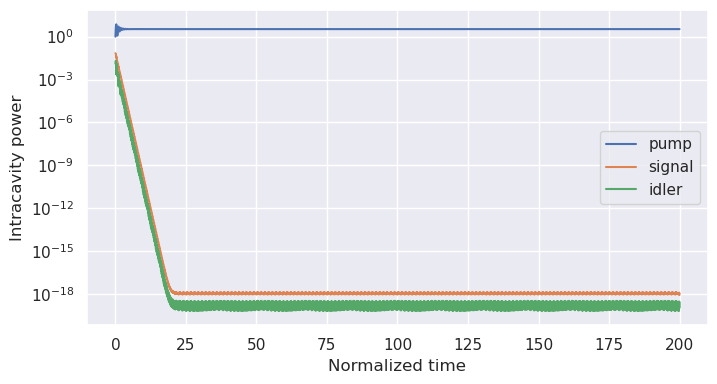

In [150]:
%matplotlib inline
# ---------------------------
# Plot intracavity power
# ---------------------------

plt.figure(figsize=(7,4))

plt.plot(sol.t, np.abs(ap)**2, label="pump")
plt.plot(sol.t, np.abs(a_s)**2, label="signal")
plt.plot(sol.t, np.abs(a_i)**2, label="idler")

plt.xlabel("Normalized time")
plt.ylabel("Intracavity power")
plt.legend()
plt.tight_layout()
plt.yscale("log")
plt.show()

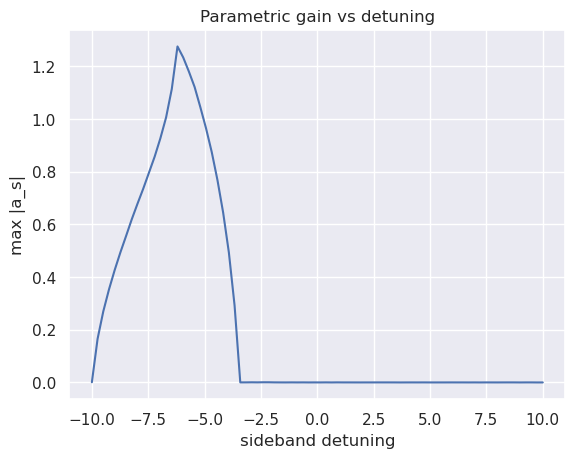

In [121]:
Delta_range = np.linspace(-10, 10, 80)
gain_signal = []

t_span = (0, 200)
t_eval = np.linspace(0,200,4000)

noise = 1e-4

for Delta in Delta_range:

    Delta_p = 2
    Delta_s = Delta
    Delta_i = Delta

    y0 = [
        0,0,
        noise*np.random.randn(), noise*np.random.randn(),
        noise*np.random.randn(), noise*np.random.randn()
    ]

    sol = solve_ivp(
        test_3mode,
        t_span,
        y0,
        t_eval=t_eval,
        rtol=1e-8,
        atol=1e-10
    )

    ap = sol.y[0] + 1j*sol.y[1]
    a_s = sol.y[2] + 1j*sol.y[3]
    a_i = sol.y[4] + 1j*sol.y[5]

    gain_signal.append(np.max(np.abs(a_s)))

plt.figure()

plt.plot(Delta_range, gain_signal)

plt.xlabel("sideband detuning")
plt.ylabel("max |a_s|")

plt.title("Parametric gain vs detuning")

plt.show()

0.12698994994442953 -0.4318200972534856
max pump power = 99.99999999999908
[ 1.00000000e+01+0.j         -2.34746645e-03-0.00029972j
 -1.07106726e-03+0.00049358j]


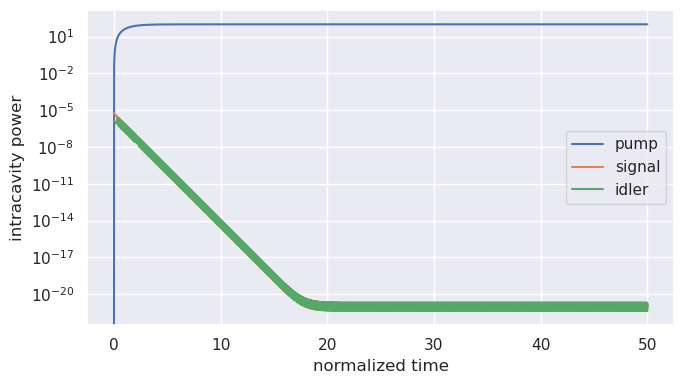

In [59]:
def test_system(t,a):

    ap, a_s, a_i = a

    dap = -ap + s

    das = -a_s -1j*(ap**2)*np.conj(a_i)
    dai = -a_i +1j*(np.conj(ap)**2)*np.conj(a_s)

    return np.array([dap, das, dai])

noise = 1e-3

a0 = np.array([
0+0j,
noise*(np.random.randn()+1j*np.random.randn()),
noise*(np.random.randn()+1j*np.random.randn())
])

print(np.angle(a0[1]), np.angle(a0[2]))

sol = solve_ivp(test_system, t_span, a0, t_eval=t_eval, rtol=1e-9, atol=1e-12)

ap = sol.y[0]
a_s = sol.y[1]
a_i = sol.y[2]

print("max pump power =", np.max(np.abs(ap)**2))

print(test_system(0, a0))
# ------------------------
# plot powers
# ------------------------

plt.figure(figsize=(7,4))

plt.plot(sol.t, np.abs(ap)**2, label="pump")
plt.plot(sol.t, np.abs(a_s)**2, label="signal")
plt.plot(sol.t, np.abs(a_i)**2, label="idler")

plt.xlabel("normalized time")
plt.ylabel("intracavity power")
plt.legend()

plt.yscale("log")

plt.tight_layout()
plt.show()



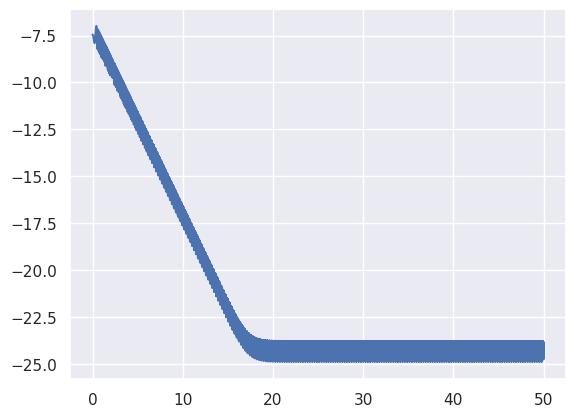

In [24]:
Delta_s = 2
Delta_i = 2

M = np.array([
    [-(1+1j*Delta_s) -1j*2*abs(ap)**2, -1j*ap**2],
    [1j*np.conj(ap)**2, -(1-1j*Delta_i) +1j*2*abs(ap)**2]
])

M
# eigvals = np.linalg.eigvals(M)

# print("Eigenvalues:")
# print(eigvals)
# print("Growth rates:",np.real(eigvals))

array([[[-1.00000000e+00-2.00000000e+00j,
         -1.00000000e+00-2.01267779e+00j,
         -1.00000000e+00-2.05020772e+00j, ...,
         -1.00000000e+00-9.83335795e+00j,
         -1.00000000e+00-9.83335795e+00j,
         -1.00000000e+00-9.83335795e+00j],
        [ 0.00000000e+00-0.00000000e+00j,
         -2.00955158e-07-6.33889438e-03j,
         -6.31253251e-06-2.51038605e-02j, ...,
         -1.87760378e+00+3.43729228e+00j,
         -1.87760378e+00+3.43729228e+00j,
         -1.87760378e+00+3.43729228e+00j]],

       [[ 0.00000000e+00+0.00000000e+00j,
         -2.00955158e-07+6.33889438e-03j,
         -6.31253251e-06+2.51038605e-02j, ...,
         -1.87760378e+00-3.43729228e+00j,
         -1.87760378e+00-3.43729228e+00j,
         -1.87760378e+00-3.43729228e+00j],
        [-1.00000000e+00+2.00000000e+00j,
         -1.00000000e+00+2.01267779e+00j,
         -1.00000000e+00+2.05020772e+00j, ...,
         -1.00000000e+00+9.83335795e+00j,
         -1.00000000e+00+9.83335795e+00j,
         

In [25]:
deltas = np.linspace(-5,5,200)
gain = []

for d in deltas:

    M = np.array([
        [-(1+1j*d) -1j*2*abs(ap)**2, -1j*ap**2],
        [1j*np.conj(ap)**2, -(1-1j*d) +1j*2*abs(ap)**2]
    ])

    eig = np.linalg.eigvals(M)

    gain.append(max(np.real(eig)))

import matplotlib.pyplot as plt

plt.plot(deltas,gain)
plt.axhline(0)
plt.xlabel("sideband detuning")
plt.ylabel("parametric gain")
plt.show()

LinAlgError: Last 2 dimensions of the array must be square